**Analysis of the pypsa .nc files**

Here we explore and plot electricity prices in different scenarios

c:\Users\alessandro.magnino\anaconda3\envs\adopt-net0\Lib\site-packages\pypsa\components.py:323: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.

c:\Users\alessandro.magnino\anaconda3\envs\adopt-net0\Lib\site-packages\pypsa\components.py:323: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.

c:\Users\alessandro.magnino\anaconda3\envs\adopt-net0\Lib\site-packages\pypsa\components.py:323: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.

c:\Users\alessandro.magnino\anaconda3



Imported network with components: []
n_buses: 966
n_buses columns: ['v_nom', 'x', 'y', 'country', 'control', 'generator', 'carrier', 'unit', 'location', 'type', 'v_mag_pu_set', 'v_mag_pu_min', 'v_mag_pu_max', 'sub_network']
Unique bus carriers (sample): ['AC' 'lignite' 'coal' 'oil' 'uranium' 'co2' 'co2 stored'
 'co2 sequestered' 'gas' 'H2' 'battery' 'Li ion' 'land transport oil'
 'urban central heat' 'urban central water tanks']
Unique countries (sample): ['', 'AL', 'AT', 'BA', 'BE', 'BG', 'CH', 'CZ', 'DE', 'DK', 'EE', 'ES', 'FI', 'FR', 'GB']

AC buses total: 37
AC buses in NL/BE/DE: 3
AC buses count by country:
 country
BE    1
DE    1
NL    1
Name: count, dtype: int64

Check denominators (hours with denominator == 0):
NL 8760.0 h
BE 8760.0 h
DE 8760.0 h




Extreme price duration (>300 €/MWh and >500 €/MWh):
NL  >300: 80.0 h  >500: 68.0 h max: 1297.56
BE  >300: 82.0 h  >500: 56.0 h max: 1306.79
DE  >300: 86.0 h  >500: 80.0 h max: 700.91


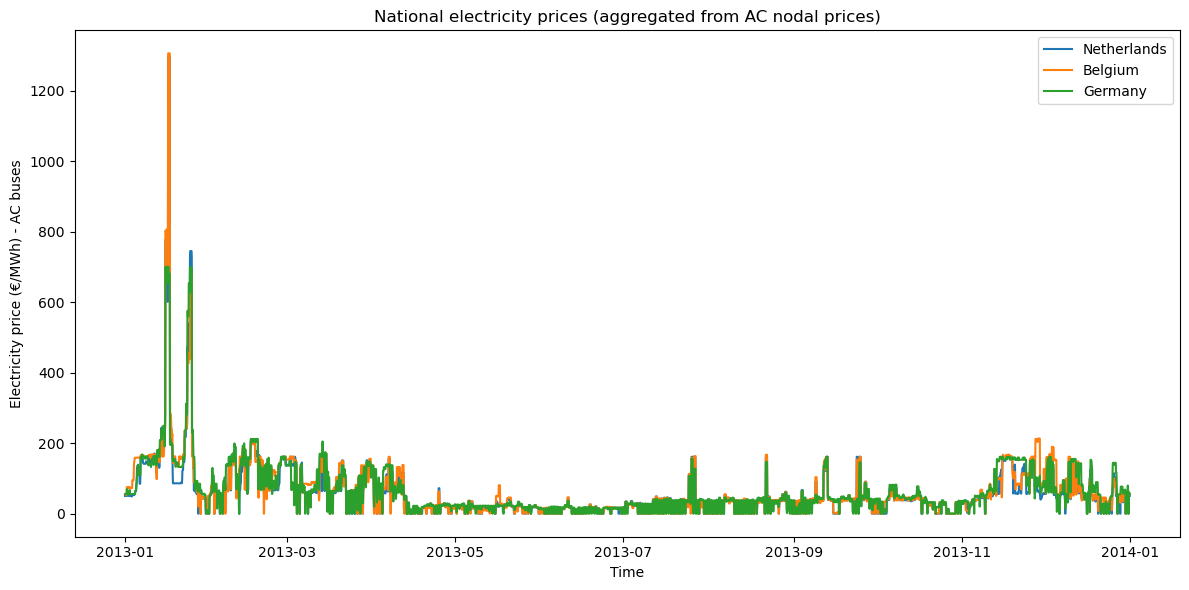


--- Spike diagnostic for BE ---
Spike at: 2013-01-16 16:00:00 value: 1306.7861902682857

Top nodal prices at spike:
Bus
BE0 0    1306.78619
Name: 2013-01-16 16:00:00, dtype: float64

AC line loadings (effective):
          flow_MW    s_nom_eff  s_max_pu      cap_eff  loading_eff
Line                                                              
14     864.514366  1754.673768       0.7  1228.271638     0.703846
13    4458.953045  9473.625137       0.7  6631.537596     0.672386
15    1188.671898  6792.410450       0.7  4754.687315     0.250000

Top link loadings:
                                                   flow_MW    p_nom_eff  \
Link                                                                      
BE0 0 urban central solid biomass CHP CC-2040     0.000014     0.000007   
BE0 0 urban central solid biomass CHP-2040        0.000024     0.000017   
BE0 0 coal-2040                                   0.000027     0.000020   
BE0 0 lignite-2040                                0.0000

In [5]:
import pandas as pd
import pypsa
import numpy as np
import matplotlib.pyplot as plt

####### 0) INPUT
# retro_tes - 2030
# path_nc = r'data/electricity_data/retro-tes_2030.nc'
# retro_tes - 2040
# path_nc = r'data/electricity_data/retro-tes_2040.nc'
# retro_tes - 2050
# path_nc = r'data/electricity_data/retro-tes_2050.nc'
# flexible - 2030
#path_nc = r'data/electricity_data/flexible_2030.nc'
# flexible - 2040
# path_nc = r'data/electricity_data/flexible_2040.nc'
# flexible - 2050
# path_nc = r'data/electricity_data/flexible_2050.nc'
# flexible_moderate - 2030
# path_nc = r'data/electricity_data/flexible-moderate_2030.nc'
# flexible_moderate - 2040
# path_nc = r'data/electricity_data/flexible-moderate_2040.nc'
# flexible_moderate - 2050
# path_nc = r'data/electricity_data/flexible-moderate_2050.nc'
# rigid - 2030
# path_nc = r'data/electricity_data/rigid_2030.nc'
# rigid - 2040
# path_nc = r'data/electricity_data/rigid_2040.nc'
# rigid - 2050
# path_nc = r'data/electricity_data/rigid_2050.nc'

path_nc = r'data\carriers_data\electricity\elec_s370_37m_lv1.1__2H-T-H-B-I-A-solar+p2-dist1-highrooftop3-cb29ex0_2040.nc'

COUNTRIES = ["NL", "BE", "DE"]

####### 1) LOAD NETWORK
n = pypsa.Network(path_nc)

def get_snapshot_hours(n):
    """
    Returns a pd.Series indexed by n.snapshots with the number of hours
    represented by each snapshot.

    Priority:
    1) infer from DatetimeIndex differences if possible
    2) fallback to n.snapshot_weightings['objective'] if available
    3) fallback to 1.0 h
    """
    snapshots = n.snapshots

    # Case 1: try from datetime spacing
    if isinstance(snapshots, pd.DatetimeIndex) and len(snapshots) >= 2:
        diffs = snapshots.to_series().diff().dt.total_seconds().div(3600.0)
        if diffs.iloc[1:].notna().all():
            # first snapshot: assume same dt as second
            diffs.iloc[0] = diffs.iloc[1]
            return diffs.rename("hours")

    # Case 2: fallback to PyPSA snapshot weightings
    if hasattr(n, "snapshot_weightings") and n.snapshot_weightings is not None:
        for col in ["objective", "generators", "stores"]:
            if col in n.snapshot_weightings.columns:
                w = n.snapshot_weightings[col].astype(float).copy()
                return w.rename("hours")

    # Case 3: safe fallback
    return pd.Series(1.0, index=snapshots, name="hours")

snapshot_hours = get_snapshot_hours(n)
dt_unique = np.sort(snapshot_hours.unique())

print(f"\n\nImported network with components:", [c for c in n.components.keys() if getattr(n, c.lower(), None) is not None])
print("n_buses:", len(n.buses))
print("n_buses columns:", n.buses.columns.tolist())
print("Unique bus carriers (sample):", n.buses["carrier"].unique()[:15] if "carrier" in n.buses.columns else "no carrier col")
print("Unique countries (sample):", sorted(n.buses["country"].dropna().unique())[:15] if "country" in n.buses.columns else "no country col")

####### 2) FILTER ELECTRIC AC BUSES + COUNTRIES
# (A) Bus AC = "wholesale electricity". We exclude buses with empty country.
ac_buses = n.buses.index[(n.buses["carrier"] == "AC") & (n.buses["country"] != "")]

# (B) Keep only NL/BE/DE
ac_buses_c = ac_buses[n.buses.loc[ac_buses, "country"].isin(COUNTRIES)]

print("\nAC buses total:", len(ac_buses))
print("AC buses in NL/BE/DE:", len(ac_buses_c))
print("AC buses count by country:\n", n.buses.loc[ac_buses_c, "country"].value_counts())

####### 3) HOURLY NODAL PRICES (ONLY ON FILTERED AC BUSES)
# Nodal prices (shadow price of nodal balance) in €/MWh
p_ac = n.buses_t.marginal_price[ac_buses_c].copy()

# map bus->country
bus_country = n.buses.loc[ac_buses_c, "country"]

####### 4) BUILD "NATIONAL" PRICE
# Path 1: simple average over AC buses of the country
p_country_mean = p_ac.T.groupby(bus_country).mean().T

# Path 2: median
p_country_median = p_ac.T.groupby(bus_country).median().T

# Path 3: load-weighted average
# - We build load per bus: sum all loads connected to the same bus.
# - We keep only the filtered AC buses.
# WARNING: if in this network the electric loads are on "low voltage" buses, here you will have many zeros in the denominator.
load_bus = n.loads_t.p_set.T.groupby(n.loads.bus).sum().T
load_bus_ac = load_bus.reindex(columns=ac_buses_c).fillna(0.0)

num = (p_ac * load_bus_ac).T.groupby(bus_country).sum().T
den = load_bus_ac.T.groupby(bus_country).sum().T

# Avoid division by zero: where den==0 set NaN
p_country_weighted = (num / den).replace([pd.NA, float("inf"), -float("inf")], pd.NA)

print("\nCheck denominators (hours with denominator == 0):")
for c in COUNTRIES:
    if c in den.columns:
        zero_hours = snapshot_hours[den[c] == 0].sum()
        print(c, f"{zero_hours:.1f} h")
    else:
        print(c, "not present in den columns")

# Choose which price to use for the plot (recommendation: mean or weighted if denominators are okay)
# If weighted has many NaN/den==0, use mean.
use_weighted = True
p_country = p_country_weighted if use_weighted else p_country_mean

# If weighted produces many NaN, automatic fallback to mean
for c in COUNTRIES:
    if c in p_country.columns:
        nan_hours = snapshot_hours[p_country[c].isna()].sum()
        nan_share = nan_hours / snapshot_hours.sum()

        if nan_share > 0.05:
            print(f"\nWARNING: {c} weighted has {nan_hours:.1f} h of NaN ({100*nan_share:.1f}%) -> fallback to mean.")
            p_country[c] = p_country_mean[c]

# Check how many hours with extreme prices
print("\nExtreme price duration (>300 €/MWh and >500 €/MWh):")
for c in COUNTRIES:
    if c not in p_country.columns:
        continue

    s = p_country[c]
    hours_gt_300 = snapshot_hours[s > 300].sum()
    hours_gt_500 = snapshot_hours[s > 500].sum()

    print(
        c,
        f" >300: {hours_gt_300:.1f} h",
        f" >500: {hours_gt_500:.1f} h",
        f"max: {s.max():.2f}"
    )

# extract series
p_NL = p_country["NL"] if "NL" in p_country.columns else None
p_BE = p_country["BE"] if "BE" in p_country.columns else None
p_DE = p_country["DE"] if "DE" in p_country.columns else None

####### 5) PLOT NATIONAL PRICES
plt.figure(figsize=(12, 6))
if p_NL is not None:
    plt.plot(p_NL.index, p_NL.values, label="Netherlands")
if p_BE is not None:
    plt.plot(p_BE.index, p_BE.values, label="Belgium")
if p_DE is not None:
    plt.plot(p_DE.index, p_DE.values, label="Germany")

plt.xlabel("Time")
plt.ylabel("Electricity price (€/MWh) - AC buses")
plt.title("National electricity prices (aggregated from AC nodal prices)")
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# 6) SPIKE DIAGNOSIS
# -----------------------------
# If you see strange spikes, check:
# A) which hour and which bus/country generates it
# B) congestion on lines/links connected to the country's bus
# Note: NL and BE often have only 1 bus (s_48), so the spike is exactly that bus.

def diagnose_spike(country_code: str):
    if country_code not in p_country.columns:
        print(f"{country_code} not in p_country.")
        return

    t_spike = p_country[country_code].idxmax()
    val = p_country[country_code].loc[t_spike]
    print(f"\n--- Spike diagnostic for {country_code} ---")
    print("Spike at:", t_spike, "value:", val)

    # buses AC in that country
    buses_c = ac_buses_c[n.buses.loc[ac_buses_c, "country"] == country_code]

    # nodal prices of those buses at that hour
    p_nodes = n.buses_t.marginal_price[buses_c].loc[t_spike].sort_values(ascending=False)
    print("\nTop nodal prices at spike:")
    print(p_nodes.head(10))

    # if country has 1 bus, take that one
    main_bus = p_nodes.index[0]

    # (1) line congestion: use effective capacity = s_nom_eff * s_max_pu
    lines = n.lines.index[(n.lines.bus0 == main_bus) | (n.lines.bus1 == main_bus)]
    if len(lines):
        flow = n.lines_t.p0.loc[t_spike, lines].abs()
        s_nom_eff = n.lines.loc[lines, "s_nom_opt"].fillna(n.lines.loc[lines, "s_nom"])
        s_max_pu = n.lines.loc[lines, "s_max_pu"].fillna(1.0)
        cap_eff = s_nom_eff * s_max_pu
        loading_eff = (flow / cap_eff).sort_values(ascending=False)

        out = pd.DataFrame({
            "flow_MW": flow,
            "s_nom_eff": s_nom_eff,
            "s_max_pu": s_max_pu,
            "cap_eff": cap_eff,
            "loading_eff": loading_eff
        }).sort_values("loading_eff", ascending=False)

        print("\nAC line loadings (effective):")
        print(out.head(10))
    else:
        print("\nNo AC lines connected to", main_bus)

    # (2) link congestion: use p_nom_eff (opt if present)
    links = n.links.index[(n.links.bus0 == main_bus) | (n.links.bus1 == main_bus)]
    if len(links):
        # effective capacity p_nom_eff (opt if present)
        p_nom_eff = n.links.loc[links, "p_nom_opt"].fillna(n.links.loc[links, "p_nom"])
        flow = n.links_t.p0.loc[t_spike, links].abs()
        loading = (flow / p_nom_eff).sort_values(ascending=False)

        outL = pd.DataFrame({
            "flow_MW": flow,
            "p_nom_eff": p_nom_eff,
            "loading": loading,
            "carrier": n.links.loc[links, "carrier"].astype(str)
        }).sort_values("loading", ascending=False)

        print("\nTop link loadings:")
        print(outL.head(15))

        # details of suspicious links (loading>0.99)
        suspicious = outL[outL["loading"] > 0.99].head(10).index
        if len(suspicious):
            cols = [c for c in ["carrier","bus0","bus1","efficiency","marginal_cost","capital_cost"] if c in n.links.columns]
            print("\nSuspicious links details (loading>0.99):")
            print(n.links.loc[suspicious, cols])
    else:
        print("\nNo links connected to", main_bus)

def weighted_time_mean(series, weights):
    mask = series.notna()
    if mask.sum() == 0:
        return np.nan
    return (series[mask] * weights[mask]).sum() / weights[mask].sum()

#
diagnose_spike("BE")
diagnose_spike("NL")
diagnose_spike("DE")

print("\nTime-weighted annual price statistics:")
for c in COUNTRIES:
    if c not in p_country.columns:
        continue

    s = p_country[c]
    avg_price = weighted_time_mean(s, snapshot_hours)
    p95 = s.quantile(0.95)
    p99 = s.quantile(0.99)

    print(
        c,
        f"avg={avg_price:.2f} €/MWh,",
        f"p95={p95:.2f},",
        f"p99={p99:.2f}"
    )


INFO:pypsa.io:Imported network flexible_2040.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores



NETWORK SUMMARY
File: flexible_2040.nc
Snapshots: 8760
Timestep(s): 1.0 h
Represented hours: 8760.0 h
Buses: 929 | Loads: 631 | Lines: 72 | Links: 3420

AC BUS SELECTION
Total AC country buses: 48
Selected AC buses (['NL', 'BE', 'DE']): 7
country
DE    5
BE    1
NL    1
Name: n_buses, dtype: int64

PRICE SUMMARY
                      aggregation  avg_price     p95     p99     max  \
country                                                                
NL       mean (weighted fallback)      57.70  201.05  326.04  788.75   
BE       mean (weighted fallback)      63.74  213.91  324.48  732.10   
DE       mean (weighted fallback)      71.86  228.25  331.32  696.19   

         zero_load_hours  nan_hours  hours_gt_300  hours_gt_500  
country                                                          
NL                8760.0        0.0         137.0          66.0  
BE                8760.0        0.0         138.0          66.0  
DE                8760.0        0.0         148.0          6

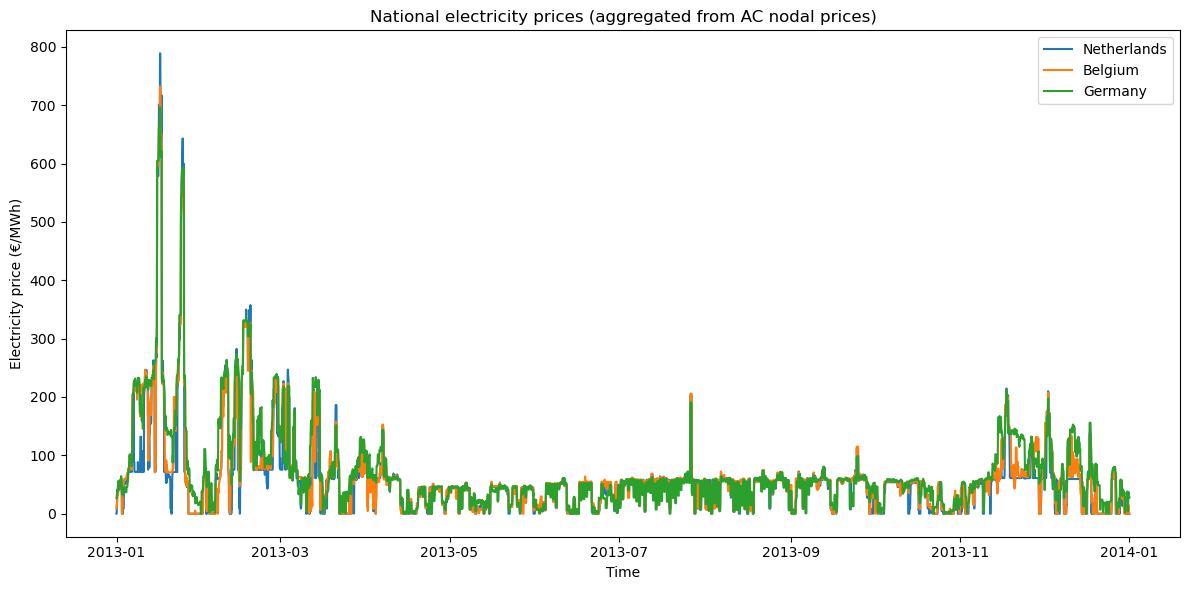


SPIKE REPORT - BE
Peak timestamp : 2013-01-16 16:00:00
Peak price     : 732.10 €/MWh
Main AC bus    : BE1 0
Aggregation    : mean (weighted fallback)

Nodal prices on AC buses in country at spike:
Bus
BE1 0    732.1

Top AC lines near bus (3 with loading >= 0.98):
       flow_MW  cap_eff_MW  loading   bus0   bus1
Line                                             
15    1340.608    1340.607    1.000  BE1 0  FR1 4
17    3392.943    3396.205    0.999  BE1 0  NL1 0
14    3384.113    3396.205    0.996  BE1 0  FR1 1
16     280.883     617.890    0.455  BE1 0  LU1 0

Top DC interconnectors (0 with loading >= 0.98):
       flow_MW  cap_eff_MW  loading   bus0   bus1
Link                                             
14801  5828.91    7542.329    0.773  DE1 3  BE1 0

Top local supply/conversion links (2 with loading >= 0.98):
                                                           carrier    flow_MW  cap_eff_MW  loading  marginal_cost           bus0               bus1
Link                     

In [10]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import pypsa
import matplotlib.pyplot as plt

# -------------------------------------------------------------------
# 0) SETTINGS
# -------------------------------------------------------------------
warnings.filterwarnings("ignore", category=FutureWarning, module="pypsa")

# -------------------------------------------------------------------
# 0) INPUT LIST
# -------------------------------------------------------------------
### From "Flattening the peak demand curve through energy efficient buildings - A holistic approach towards net-zero carbon"
# retro_tes - 2030
# path_nc = r'data/carriers_data/electricity/retro-tes_2030.nc'
# retro_tes - 2040
# path_nc = r'data/carriers_data/electricity/retro-tes_2040.nc'
# retro_tes - 2050
# path_nc = r'data/carriers_data/electricity/retro-tes_2050.nc'
# flexible - 2030
# path_nc = r'data/carriers_data/electricity/flexible_2030.nc'
# flexible - 2040
path_nc = r'data/carriers_data/electricity/flexible_2040.nc'
# flexible - 2050
# path_nc = r'data/carriers_data/electricity/flexible_2050.nc'
# flexible_moderate - 2030
# path_nc = r'data/carriers_data/electricity/flexible-moderate_2030.nc'
# flexible_moderate - 2040
# path_nc = r'data/carriers_data/electricity/flexible-moderate_2040.nc'
# flexible_moderate - 2050
# path_nc = r'data/carriers_data/electricity/flexible-moderate_2050.nc'
# rigid - 2030
# path_nc = r'data/carriers_data/electricity/rigid_2030.nc'
# rigid - 2040
# path_nc = r'data/carriers_data/electricity/rigid_2040.nc'
# rigid - 2050
# path_nc = r'data/carriers_data/electricity/rigid_2050.nc'

### From "Strategic deployment of solar photovoltaics for achieving self-sufficiency in Europe throughout the energy transition"
# base - 2030
# path_nc = r"data\carriers_data\electricity\elec_s370_37m_lv1.1__2H-T-H-B-I-A-solar+p2-dist1-highrooftop3-cb29ex0_2030.nc"
# base - 2040
# path_nc = r"data\carriers_data\electricity\elec_s370_37m_lv1.1__2H-T-H-B-I-A-solar+p2-dist1-highrooftop3-cb29ex0_2040.nc"
# base - 2050
# path_nc = r"data\carriers_data\electricity\elec_s370_37m_lv1.1__2H-T-H-B-I-A-solar+p2-dist1-highrooftop3-cb29ex0_2050.nc"
# newsolar - 2030
# path_nc = r"data\carriers_data\electricity\elec_s370_37m_lv1.1__2H-T-H-B-I-A-solar+p2-dist1-highrooftop3-newsolar-cb29ex0_2030.nc"
# newsolar - 2040
# path_nc = r"data\carriers_data\electricity\elec_s370_37m_lv1.1__2H-T-H-B-I-A-solar+p2-dist1-highrooftop3-newsolar-cb29ex0_2040.nc"
# newsolar - 2050
# path_nc = r"data\carriers_data\electricity\elec_s370_37m_lv1.1__2H-T-H-B-I-A-solar+p2-dist1-highrooftop3-newsolar-cb29ex0_2050.nc"


COUNTRIES = ["NL", "BE", "DE"]

USE_WEIGHTED = True
WEIGHTED_NAN_THRESHOLD = 0.05   # fallback to mean if >5% NaN hours

PRICE_THRESHOLDS = [300, 500]

# Filters for spike diagnostics: remove numerical dust / irrelevant tiny assets
MIN_LINE_FLOW_MW = 10.0
MIN_LINE_CAP_MW = 100.0

MIN_DC_FLOW_MW = 10.0
MIN_DC_CAP_MW = 100.0

MIN_LOCAL_FLOW_MW = 10.0
MIN_LOCAL_CAP_MW = 10.0

CONGESTION_THRESHOLD = 0.98

TOP_N_LINES = 5
TOP_N_DC = 5
TOP_N_LOCAL = 8

SHOW_PLOT = True
DIAGNOSE_COUNTRIES = ["BE", "NL", "DE"]


# -------------------------------------------------------------------
# 1) HELPERS
# -------------------------------------------------------------------
def get_snapshot_hours(n):
    """
    Returns a pd.Series indexed by n.snapshots with the number of hours
    represented by each snapshot.
    """
    snapshots = n.snapshots

    if isinstance(snapshots, pd.DatetimeIndex) and len(snapshots) >= 2:
        diffs = snapshots.to_series().diff().dt.total_seconds().div(3600.0)
        if diffs.iloc[1:].notna().all():
            diffs.iloc[0] = diffs.iloc[1]
            return diffs.rename("hours")

    if hasattr(n, "snapshot_weightings") and n.snapshot_weightings is not None:
        for col in ["objective", "generators", "stores"]:
            if col in n.snapshot_weightings.columns:
                return n.snapshot_weightings[col].astype(float).rename("hours")

    return pd.Series(1.0, index=snapshots, name="hours")


def weighted_time_mean(series, weights):
    mask = series.notna()
    if mask.sum() == 0:
        return np.nan
    return (series[mask] * weights[mask]).sum() / weights[mask].sum()


def fmt_hours(x):
    return f"{x:.1f} h"


def fmt_float(x, nd=2):
    if pd.isna(x):
        return "NaN"
    return f"{x:.{nd}f}"


def print_header(title):
    print("\n" + "=" * 80)
    print(title)
    print("=" * 80)


def safe_divide(num, den):
    out = num / den
    return out.replace([np.inf, -np.inf], np.nan)


def top_df(df, n=5, cols=None):
    if df is None or df.empty:
        return None
    if cols is not None:
        cols = [c for c in cols if c in df.columns]
        return df.loc[:, cols].head(n)
    return df.head(n)


# -------------------------------------------------------------------
# 2) LOAD NETWORK
# -------------------------------------------------------------------
n = pypsa.Network(path_nc)
snapshot_hours = get_snapshot_hours(n)
dt_unique = np.sort(snapshot_hours.unique())

print_header("NETWORK SUMMARY")
print(f"File: {Path(path_nc).name}")
print(f"Snapshots: {len(n.snapshots)}")
print(f"Timestep(s): {', '.join([str(x) for x in dt_unique])} h")
print(f"Represented hours: {snapshot_hours.sum():.1f} h")
print(f"Buses: {len(n.buses)} | Loads: {len(n.loads)} | Lines: {len(n.lines)} | Links: {len(n.links)}")


# -------------------------------------------------------------------
# 3) FILTER ELECTRIC AC BUSES
# -------------------------------------------------------------------
ac_buses = n.buses.index[(n.buses["carrier"] == "AC") & (n.buses["country"] != "")]
ac_buses_c = ac_buses[n.buses.loc[ac_buses, "country"].isin(COUNTRIES)]
bus_country = n.buses.loc[ac_buses_c, "country"]

print_header("AC BUS SELECTION")
print(f"Total AC country buses: {len(ac_buses)}")
print(f"Selected AC buses ({COUNTRIES}): {len(ac_buses_c)}")
print(n.buses.loc[ac_buses_c, "country"].value_counts().rename("n_buses"))


# -------------------------------------------------------------------
# 4) NODAL PRICES AND NATIONAL SERIES
# -------------------------------------------------------------------
p_ac = n.buses_t.marginal_price[ac_buses_c].copy()

# Path 1: simple mean across AC buses of the country
p_country_mean = p_ac.T.groupby(bus_country).mean().T

# Path 2: median across AC buses of the country
p_country_median = p_ac.T.groupby(bus_country).median().T

# Path 3: load-weighted average across AC buses of the country
# WARNING: if electric loads are on LV buses, denominator can be zero
load_bus = n.loads_t.p_set.T.groupby(n.loads.bus).sum().T
load_bus_ac = load_bus.reindex(columns=ac_buses_c).fillna(0.0)

num = (p_ac * load_bus_ac).T.groupby(bus_country).sum().T
den = load_bus_ac.T.groupby(bus_country).sum().T
p_country_weighted = safe_divide(num, den)

p_country = p_country_weighted.copy() if USE_WEIGHTED else p_country_mean.copy()

# keep track of which aggregation is actually used
aggregation_used = {}

for c in COUNTRIES:
    if c not in p_country.columns:
        continue

    if USE_WEIGHTED:
        nan_hours = snapshot_hours[p_country[c].isna()].sum()
        nan_share = nan_hours / snapshot_hours.sum()

        if nan_share > WEIGHTED_NAN_THRESHOLD:
            p_country[c] = p_country_mean[c]
            aggregation_used[c] = "mean (weighted fallback)"
        else:
            aggregation_used[c] = "weighted"
    else:
        aggregation_used[c] = "mean"


# -------------------------------------------------------------------
# 5) COUNTRY SUMMARY TABLE
# -------------------------------------------------------------------
summary_rows = []

for c in COUNTRIES:
    if c not in p_country.columns:
        continue

    s = p_country[c]
    row = {
        "country": c,
        "aggregation": aggregation_used.get(c, "n/a"),
        "avg_price": weighted_time_mean(s, snapshot_hours),
        "p95": s.quantile(0.95),
        "p99": s.quantile(0.99),
        "max": s.max(),
        "zero_load_hours": snapshot_hours[den[c] == 0].sum() if c in den.columns else np.nan,
        "nan_hours": snapshot_hours[s.isna()].sum(),
    }

    for thr in PRICE_THRESHOLDS:
        row[f"hours_gt_{thr}"] = snapshot_hours[s > thr].sum()

    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index("country")

print_header("PRICE SUMMARY")
display_cols = [
    "aggregation", "avg_price", "p95", "p99", "max",
    "zero_load_hours", "nan_hours"
] + [f"hours_gt_{thr}" for thr in PRICE_THRESHOLDS]

summary_to_print = summary_df[display_cols].copy()
num_cols = summary_to_print.select_dtypes(include=[np.number]).columns
summary_to_print[num_cols] = summary_to_print[num_cols].round(2)
print(summary_to_print)


# -------------------------------------------------------------------
# 6) PLOT
# -------------------------------------------------------------------
if SHOW_PLOT:
    plt.figure(figsize=(12, 6))

    labels = {"NL": "Netherlands", "BE": "Belgium", "DE": "Germany"}
    for c in COUNTRIES:
        if c in p_country.columns:
            plt.plot(p_country.index, p_country[c].values, label=labels.get(c, c))

    plt.xlabel("Time")
    plt.ylabel("Electricity price (€/MWh)")
    plt.title("National electricity prices (aggregated from AC nodal prices)")
    plt.legend()
    plt.tight_layout()
    plt.show()


# -------------------------------------------------------------------
# 7) SPIKE DIAGNOSTICS
# -------------------------------------------------------------------
def get_country_main_bus(country_code, t_spike):
    buses_c = ac_buses_c[n.buses.loc[ac_buses_c, "country"] == country_code]
    if len(buses_c) == 0:
        return None, None

    p_nodes = n.buses_t.marginal_price[buses_c].loc[t_spike].sort_values(ascending=False)
    if p_nodes.empty:
        return None, None

    main_bus = p_nodes.index[0]
    return main_bus, p_nodes


def build_line_loading_table(main_bus, t_spike):
    lines = n.lines.index[(n.lines.bus0 == main_bus) | (n.lines.bus1 == main_bus)]
    if len(lines) == 0:
        return pd.DataFrame()

    flow = n.lines_t.p0.loc[t_spike, lines].abs()
    s_nom_eff = n.lines.loc[lines, "s_nom_opt"].fillna(n.lines.loc[lines, "s_nom"])
    s_max_pu = n.lines.loc[lines, "s_max_pu"].fillna(1.0)
    cap_eff = s_nom_eff * s_max_pu
    loading_eff = safe_divide(flow, cap_eff)

    out = pd.DataFrame({
        "flow_MW": flow,
        "cap_eff_MW": cap_eff,
        "loading": loading_eff,
        "bus0": n.lines.loc[lines, "bus0"],
        "bus1": n.lines.loc[lines, "bus1"],
    }).dropna(subset=["loading"])

    out = out[(out["flow_MW"] >= MIN_LINE_FLOW_MW) & (out["cap_eff_MW"] >= MIN_LINE_CAP_MW)]
    out = out.sort_values("loading", ascending=False)
    return out


def build_link_loading_table(main_bus, t_spike):
    links = n.links.index[(n.links.bus0 == main_bus) | (n.links.bus1 == main_bus)]
    if len(links) == 0:
        return pd.DataFrame()

    p_nom_eff = n.links.loc[links, "p_nom_opt"].fillna(n.links.loc[links, "p_nom"])
    flow = n.links_t.p0.loc[t_spike, links].abs()
    loading = safe_divide(flow, p_nom_eff)

    out = pd.DataFrame({
        "flow_MW": flow,
        "cap_eff_MW": p_nom_eff,
        "loading": loading,
        "carrier": n.links.loc[links, "carrier"].astype(str),
        "bus0": n.links.loc[links, "bus0"],
        "bus1": n.links.loc[links, "bus1"],
        "efficiency": n.links.loc[links, "efficiency"] if "efficiency" in n.links.columns else np.nan,
        "marginal_cost": n.links.loc[links, "marginal_cost"] if "marginal_cost" in n.links.columns else np.nan,
    }).dropna(subset=["loading"])

    return out.sort_values("loading", ascending=False)


def split_links_tables(out_links):
    if out_links.empty:
        return pd.DataFrame(), pd.DataFrame()

    # DC interconnectors
    dc_mask = out_links["carrier"].str.upper().eq("DC")
    dc = out_links[dc_mask].copy()
    dc = dc[(dc["flow_MW"] >= MIN_DC_FLOW_MW) & (dc["cap_eff_MW"] >= MIN_DC_CAP_MW)]
    dc = dc.sort_values("loading", ascending=False)

    # local supply/conversion links
    local = out_links[~dc_mask].copy()
    local = local[(local["flow_MW"] >= MIN_LOCAL_FLOW_MW) & (local["cap_eff_MW"] >= MIN_LOCAL_CAP_MW)]
    local = local.sort_values("loading", ascending=False)

    return dc, local


def diagnose_spike(country_code):
    if country_code not in p_country.columns:
        print(f"\n{country_code}: not available in price table.")
        return

    s = p_country[country_code]
    t_spike = s.idxmax()
    spike_val = s.loc[t_spike]

    main_bus, p_nodes = get_country_main_bus(country_code, t_spike)
    if main_bus is None:
        print(f"\n{country_code}: no AC bus found.")
        return

    lines_tbl = build_line_loading_table(main_bus, t_spike)
    links_tbl = build_link_loading_table(main_bus, t_spike)
    dc_tbl, local_tbl = split_links_tables(links_tbl)

    print_header(f"SPIKE REPORT - {country_code}")
    print(f"Peak timestamp : {t_spike}")
    print(f"Peak price     : {spike_val:.2f} €/MWh")
    print(f"Main AC bus    : {main_bus}")
    print(f"Aggregation    : {aggregation_used.get(country_code, 'n/a')}")
    print()

    if p_nodes is not None:
        print("Nodal prices on AC buses in country at spike:")
        print(p_nodes.round(2).to_string())
        print()

    if not lines_tbl.empty:
        n_cong_lines = (lines_tbl["loading"] >= CONGESTION_THRESHOLD).sum()
        print(f"Top AC lines near bus ({n_cong_lines} with loading >= {CONGESTION_THRESHOLD:.2f}):")
        print(
            top_df(
                lines_tbl.round(3),
                n=TOP_N_LINES,
                cols=["flow_MW", "cap_eff_MW", "loading", "bus0", "bus1"]
            ).to_string()
        )
        print()
    else:
        print("Top AC lines near bus: none above significance thresholds.\n")

    if not dc_tbl.empty:
        n_cong_dc = (dc_tbl["loading"] >= CONGESTION_THRESHOLD).sum()
        print(f"Top DC interconnectors ({n_cong_dc} with loading >= {CONGESTION_THRESHOLD:.2f}):")
        print(
            top_df(
                dc_tbl.round(3),
                n=TOP_N_DC,
                cols=["flow_MW", "cap_eff_MW", "loading", "bus0", "bus1"]
            ).to_string()
        )
        print()
    else:
        print("Top DC interconnectors: none above significance thresholds.\n")

    if not local_tbl.empty:
        n_sat_local = (local_tbl["loading"] >= CONGESTION_THRESHOLD).sum()
        print(f"Top local supply/conversion links ({n_sat_local} with loading >= {CONGESTION_THRESHOLD:.2f}):")
        print(
            top_df(
                local_tbl.round(3),
                n=TOP_N_LOCAL,
                cols=["carrier", "flow_MW", "cap_eff_MW", "loading", "marginal_cost", "bus0", "bus1"]
            ).to_string()
        )
        print()
    else:
        print("Top local supply/conversion links: none above significance thresholds.\n")


# -------------------------------------------------------------------
# 8) RUN SPIKE REPORTS
# -------------------------------------------------------------------
for c in DIAGNOSE_COUNTRIES:
    diagnose_spike(c)

**Non-recoverable fees**

We fetch data from Eurostat database, considering "Excluding taxes and levies" and "Excluding VAT and other recoverable taxes and levies" values, and we subtract the two values to find the non-recoverable taxes

In [ ]:
import requests
import pandas as pd
from urllib.parse import quote

def fetch_dbnomics_series(provider: str, dataset: str, series_code: str) -> pd.Series:
    """
    Fetch Eurostat nrg_pc_205 series through DBnomics Web API.
    Returns a pandas Series indexed by period_start_day (datetime), values in €/kWh.
    """
    base = f"https://api.db.nomics.world/v22/series/{provider}/{dataset}/{quote(series_code, safe='.')}"
    params = {"observations": 1, "metadata": 0}

    r = requests.get(base, params=params, timeout=60)
    r.raise_for_status()
    js = r.json()

    doc = js["series"]["docs"][0]

    # Se manca, significa che non sono arrivate le osservazioni
    if "period_start_day" not in doc or "value" not in doc:
        raise RuntimeError(
            f"Nessuna osservazione nella risposta. "
            f"Controlla observations=1. Keys disponibili: {list(doc.keys())}"
        )

    idx = pd.to_datetime(doc["period_start_day"])
    s = pd.Series(doc["value"], index=idx, name=series_code).sort_index()

    return s

countries = ["NL", "BE", "DE"]

no_tax_code = 'X_TAX'
no_vat_code = 'X_VAT'

fee_df = pd.DataFrame(columns=countries)

for country in countries:
    no_tax_series_code = f"S.6000.MWH_GE150000.KWH.{no_tax_code}.EUR.{country}"
    no_vat_series_code = f"S.6000.MWH_GE150000.KWH.{no_vat_code}.EUR.{country}"
    no_tax = fetch_dbnomics_series("Eurostat", "nrg_pc_205", no_tax_series_code)
    no_vat = fetch_dbnomics_series("Eurostat", "nrg_pc_205", no_vat_series_code)

    fee_df[country] = (no_vat - no_tax) * 1000  # convert to €/MWh


print(fee_df.tail())

**Save results to csv**

This script builds **all-in electricity price time series** for **NL, BE, and DE** by combining  
hourly **PyPSA AC marginal prices** with additional **country-specific fees** retrieved from  
**Eurostat via DBnomics**. For each scenario network (`.nc`), it filters AC buses, aggregates  
nodal prices by country, and adds the latest available fee value for that country. The resulting  
hourly all-in prices are exported to CSV, together with a summary file reporting basic statistics  
such as mean price, maximum price, and the number of hours above selected thresholds.

In [ ]:
import os
import re
import pypsa
import pandas as pd
import requests
from urllib.parse import quote

COUNTRIES = ["NL", "BE", "DE"]

def fetch_dbnomics_series(provider: str, dataset: str, series_code: str) -> pd.Series:
    """
    Fetch Eurostat nrg_pc_205 series through DBnomics Web API.
    Returns a pandas Series indexed by period_start_day (datetime), values in €/kWh.
    """
    base = f"https://api.db.nomics.world/v22/series/{provider}/{dataset}/{quote(series_code, safe='.')}"
    params = {"observations": 1, "metadata": 0}

    r = requests.get(base, params=params, timeout=60)
    r.raise_for_status()
    js = r.json()

    doc = js["series"]["docs"][0]

    # if missing, means no observations returned
    if "period_start_day" not in doc or "value" not in doc:
        raise RuntimeError(
            f"No observations in response. "
            f"Check observations=1. Available keys: {list(doc.keys())}"
        )

    idx = pd.to_datetime(doc["period_start_day"])
    s = pd.Series(doc["value"], index=idx, name=series_code).sort_index()

    return s

def get_fee_dataframe(countries=COUNTRIES) -> pd.DataFrame:
    """
    Fetch fee DataFrame from Eurostat via DBnomics.
    Returns DataFrame with datetime index and country columns (€/MWh).
    """
    no_tax_code = 'X_TAX'
    no_vat_code = 'X_VAT'

    fee_df = pd.DataFrame(columns=countries)

    for country in countries:
        no_tax_series_code = f"S.6000.MWH_GE150000.KWH.{no_tax_code}.EUR.{country}"
        no_vat_series_code = f"S.6000.MWH_GE150000.KWH.{no_vat_code}.EUR.{country}"
        no_tax = fetch_dbnomics_series("Eurostat", "nrg_pc_205", no_tax_series_code)
        no_vat = fetch_dbnomics_series("Eurostat", "nrg_pc_205", no_vat_series_code)

        fee_df[country] = (no_vat - no_tax) * 1000  # convert to €/MWh

    return fee_df

def extract_ac_country_prices(n: pypsa.Network, countries=COUNTRIES, agg="mean") -> pd.DataFrame:
    """
    Extract electric prices (carrier='AC') and aggregate by country.
    agg: 'mean' or 'median'
    Returns DataFrame with datetime index and country columns.
    """
    # 1) filter AC buses with non-empty country
    ac_buses = n.buses.index[(n.buses["carrier"] == "AC") & (n.buses["country"] != "")]
    ac_buses = ac_buses[n.buses.loc[ac_buses, "country"].isin(countries)]

    if len(ac_buses) == 0:
        raise ValueError("No AC buses found for the requested countries. Check carrier/country in the network.")

    # 2) nodal prices on filtered AC buses
    p_ac = n.buses_t.marginal_price[ac_buses].copy()
    bus_country = n.buses.loc[ac_buses, "country"]

    # 3) aggregation by country (avoid deprecated axis=1)
    if agg == "mean":
        p_country = p_ac.T.groupby(bus_country).mean().T
    elif agg == "median":
        p_country = p_ac.T.groupby(bus_country).median().T
    else:
        raise ValueError("agg must be 'mean' or 'median'")

    # 4) keep only requested columns and in order
    p_country = p_country.reindex(columns=countries)

    # (optional) ensure index is datetime
    p_country.index = pd.to_datetime(p_country.index)

    return p_country


def scenario_name_from_path(path_nc: str) -> str:
    """
    Crea un nome file sensato a partire dal path.
    Esempio: flexible_2050.nc -> flexible_2050
    """
    base = os.path.basename(path_nc)
    name = re.sub(r"\.nc$", "", base)
    return name


def export_scenario_csv(path_nc: str, out_dir: str, fees_last: pd.Series, countries=COUNTRIES, agg="mean") -> pd.DataFrame:
    """
    Load network, extract prices, export CSV.
    Returns the exported DataFrame.
    """
    n = pypsa.Network(path_nc)
    df = extract_ac_country_prices(n, countries=countries, agg=agg)

    df_allin = df.add(fees_last, axis="columns")

    scen = scenario_name_from_path(path_nc)
    out_csv = os.path.join(out_dir, f"prices_AC_allin_{scen}.csv")

    # CSV with datetime index
    df_allin.to_csv(out_csv, index=True)

    print(f"[OK] Saved: {out_csv}  | shape={df_allin.shape}")
    
    return df_allin


def summarize_prices(df: pd.DataFrame) -> pd.DataFrame:
    """
    Quick statistics for sanity-check.
    """
    summary = pd.DataFrame({
        "mean": df.mean(),
        "max": df.max(),
        "hours_gt_300": (df > 300).sum(),
        "hours_gt_500": (df > 500).sum(),
    })
    return summary


# -------------------------
# INPUT: scenario .nc files
# -------------------------

fees_df = get_fee_dataframe(COUNTRIES)

fees_last = fees_df.apply(lambda col: col.dropna().iloc[-1], axis=0)
fees_last = fees_last.reindex(COUNTRIES)

nc_files = [
    r"data/carriers_data/electricity/flexible_2030.nc",
    r"data/carriers_data/electricity/flexible_2040.nc",
    r"data/carriers_data/electricity/flexible_2050.nc",
    r"data/carriers_data/electricity/flexible-moderate_2030.nc",
    r"data/carriers_data/electricity/flexible-moderate_2040.nc",
    r"data/carriers_data/electricity/flexible-moderate_2050.nc",
    r"data/carriers_data/electricity/retro-tes_2030.nc",
    r"data/carriers_data/electricity/retro-tes_2040.nc",
    r"data/carriers_data/electricity/retro-tes_2050.nc",
    r"data/carriers_data/electricity/rigid_2030.nc",
    r"data/carriers_data/electricity/rigid_2040.nc",
    r"data/carriers_data/electricity/rigid_2050.nc",
]

out_dir = r"data/carriers_data/electricity"

all_summaries = []

for path_nc in nc_files:
    if not os.path.exists(path_nc):
        print(f"[SKIP] missing file: {path_nc}")
        continue

    df_allin = export_scenario_csv(path_nc, out_dir, fees_last, countries=COUNTRIES, agg="mean")

    summ = summarize_prices(df_allin)
    summ["scenario"] = scenario_name_from_path(path_nc)
    all_summaries.append(summ.reset_index().rename(columns={"index": "country"}))

if all_summaries:
    summary_df = pd.concat(all_summaries, ignore_index=True)
    summary_path = os.path.join(out_dir, "summary_prices_allin.csv")
    summary_df.to_csv(summary_path, index=False)
    print(f"[OK] Saved summary: {summary_path}")


In [ ]:
import numpy as np
import pandas as pd

COUNTRIES = ["NL", "BE", "DE"]

def _get_ts(n, component_t, key):
    # robust: n.links_t.p2 oppure n.links_t["p2"]
    if hasattr(component_t, key):
        return getattr(component_t, key)
    return component_t[key]

def _fix_sign(df):
    # se è "quasi tutto" negativo, ribalta
    if df.size == 0:
        return df
    return (-df) if df.to_numpy().mean() < 0 else df

def national_ci_from_co2_ports(n, countries, elec_carrier="AC"):
    # AC buses in selected countries
    ac_buses = n.buses.index[(n.buses["carrier"] == elec_carrier) & (n.buses["country"] != "")]
    ac_buses_c = ac_buses[n.buses.loc[ac_buses, "country"].isin(countries)]
    bus_country = n.buses.loc[ac_buses_c, "country"]

    # -------------------------
    # (A) Electricity denominator (MWh/h)
    # -------------------------
    # Generators on AC buses
    gens = n.generators.index[n.generators.bus.isin(ac_buses_c)]
    gen_el = n.generators_t.p[gens].clip(lower=0.0) if len(gens) else pd.DataFrame(index=n.snapshots)
    gen_el_country = (
        gen_el.T.groupby(n.generators.loc[gens, "bus"].map(bus_country)).sum().T
        if len(gens) else pd.DataFrame(0.0, index=n.snapshots, columns=countries)
    )

    # Links injecting into AC buses (bus1 is AC)
    links_el = n.links.index[n.links.bus1.isin(ac_buses_c)]
    p1 = _get_ts(n, n.links_t, "p1")[links_el] if len(links_el) else pd.DataFrame(index=n.snapshots)
    p1 = _fix_sign(p1).clip(lower=0.0)
    link_el_country = (
        p1.T.groupby(n.links.loc[links_el, "bus1"].map(bus_country)).sum().T
        if len(links_el) else pd.DataFrame(0.0, index=n.snapshots, columns=countries)
    )

    E_MWh = gen_el_country.add(link_el_country, fill_value=0.0)

    # -------------------------
    # (B) CO2 flows (tCO2/h) from link extra ports
    # -------------------------
    def co2_to(target_bus_name):
        co2 = pd.DataFrame(0.0, index=n.snapshots, columns=E_MWh.columns)
        for k in [2, 3, 4]:
            busk = f"bus{k}"
            pk = f"p{k}"
            if busk in n.links.columns and pk in n.links_t.keys():
                mask = (n.links[busk] == target_bus_name) & (n.links.bus1.isin(ac_buses_c))
                if mask.any():
                    p = _get_ts(n, n.links_t, pk)[mask.index[mask]]
                    p = _fix_sign(p).clip(lower=0.0)
                    co2_c = p.T.groupby(n.links.loc[mask.index[mask], "bus1"].map(bus_country)).sum().T
                    co2 = co2.add(co2_c, fill_value=0.0)
        return co2

    CO2_atm_t   = co2_to("co2 atmosphere")
    CO2_store_t = co2_to("co2 stored")
    CO2_seq_t   = co2_to("co2 sequestered")

    # -------------------------
    # (C) Intensities
    # -------------------------
    CI_net_kg_per_MWh = (1000.0 * CO2_atm_t / E_MWh).replace([np.inf, -np.inf], np.nan)
    CI_gross_kg_per_MWh = (1000.0 * (CO2_atm_t + CO2_store_t + CO2_seq_t) / E_MWh).replace([np.inf, -np.inf], np.nan)

    return CI_net_kg_per_MWh, CI_gross_kg_per_MWh, E_MWh, CO2_atm_t, CO2_store_t, CO2_seq_t

ci_net, ci_gross, E, co2_atm, co2_store, co2_seq = national_ci_from_co2_ports(n, COUNTRIES)

print("Electricity denominator: hours with E==0")
for c in COUNTRIES:
    if c in E.columns:
        print(c, (E[c] == 0).sum())

print("\nCI net (kg/MWh) summary:")
print(ci_net[COUNTRIES].describe(percentiles=[0.5, 0.9, 0.99]))

# Plot net CI
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
for c in COUNTRIES:
    plt.plot(ci_net.index, ci_net[c].values, label=c)
plt.ylabel("Carbon intensity net (kgCO₂/MWh)")
plt.xlabel("Time")
plt.title("Hourly electricity carbon intensity (net to atmosphere) - AC buses")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import os
import re
import pypsa
import pandas as pd
import numpy as np

COUNTRIES = ["NL", "BE", "DE"]

# -------------------------
# Helpers
# -------------------------
def _get_ts(component_t, key):
    return getattr(component_t, key) if hasattr(component_t, key) else component_t[key]

def _fix_sign(df):
    """If series is mostly negative, flip sign (sign-convention safeguard)."""
    if df.size == 0:
        return df
    return (-df) if df.to_numpy().mean() < 0 else df

def scenario_name_from_path(path_nc: str) -> str:
    base = os.path.basename(path_nc)
    return re.sub(r"\.nc$", "", base)

# -------------------------
# Core extraction: CI from CO2 ports
# -------------------------
def extract_ac_country_carbon_intensity(
    n: pypsa.Network,
    countries=COUNTRIES,
    mode="net",  # "net" or "gross"
) -> dict:
    """
    Production-based carbon intensity on AC buses by country.
    mode:
      - "net": only CO2 -> 'co2 atmosphere'
      - "gross": CO2 -> atmosphere + stored + sequestered

    Returns dict with:
      ci (kgCO2/MWh), E_MWh (MWh/h), CO2_atm_t (tCO2/h), CO2_store_t, CO2_seq_t
    """
    elec_carrier = "AC"

    # 1) filter AC buses with non-empty country and in target list
    ac_buses = n.buses.index[(n.buses["carrier"] == elec_carrier) & (n.buses["country"] != "")]
    ac_buses_c = ac_buses[n.buses.loc[ac_buses, "country"].isin(countries)]
    if len(ac_buses_c) == 0:
        raise ValueError("No AC buses found for requested countries (carrier/country mismatch).")

    bus_country = n.buses.loc[ac_buses_c, "country"]

    # -------------------------
    # (A) Electricity denominator (MWh/h)
    # -------------------------
    # Generators on AC buses
    gens = n.generators.index[n.generators.bus.isin(ac_buses_c)]
    gen_el = n.generators_t.p[gens].clip(lower=0.0) if len(gens) else pd.DataFrame(index=n.snapshots)
    gen_el_country = (
        gen_el.T.groupby(n.generators.loc[gens, "bus"].map(bus_country)).sum().T
        if len(gens) else pd.DataFrame(0.0, index=n.snapshots, columns=countries)
    )

    # Links injecting into AC buses (bus1 is AC)
    links_el = n.links.index[n.links.bus1.isin(ac_buses_c)]
    p1 = _get_ts(n.links_t, "p1")[links_el] if len(links_el) else pd.DataFrame(index=n.snapshots)
    p1 = _fix_sign(p1).clip(lower=0.0)
    link_el_country = (
        p1.T.groupby(n.links.loc[links_el, "bus1"].map(bus_country)).sum().T
        if len(links_el) else pd.DataFrame(0.0, index=n.snapshots, columns=countries)
    )

    E_MWh = gen_el_country.add(link_el_country, fill_value=0.0).reindex(columns=countries, fill_value=0.0)
    E_MWh.index = pd.to_datetime(E_MWh.index)

    # -------------------------
    # (B) CO2 flows (tCO2/h) from link extra ports
    # -------------------------
    def co2_to(target_bus_name: str) -> pd.DataFrame:
        co2 = pd.DataFrame(0.0, index=n.snapshots, columns=countries)
        for k in [2, 3, 4]:
            busk, pk = f"bus{k}", f"p{k}"
            if (busk in n.links.columns) and (pk in n.links_t):
                mask = (n.links[busk] == target_bus_name) & (n.links.bus1.isin(ac_buses_c))
                if mask.any():
                    p = _get_ts(n.links_t, pk)[mask.index[mask]]
                    p = _fix_sign(p).clip(lower=0.0)
                    co2_c = p.T.groupby(n.links.loc[mask.index[mask], "bus1"].map(bus_country)).sum().T
                    co2 = co2.add(co2_c.reindex(columns=countries, fill_value=0.0), fill_value=0.0)
        co2.index = pd.to_datetime(co2.index)
        return co2

    CO2_atm_t   = co2_to("co2 atmosphere")
    CO2_store_t = co2_to("co2 stored")
    CO2_seq_t   = co2_to("co2 sequestered")

    # -------------------------
    # (C) Intensities (kgCO2/MWh)
    # -------------------------
    # Avoid inf when E=0 -> NaN
    if mode == "net":
        ci = (1000.0 * CO2_atm_t / E_MWh).replace([np.inf, -np.inf], np.nan)
    elif mode == "gross":
        ci = (1000.0 * (CO2_atm_t + CO2_store_t + CO2_seq_t) / E_MWh).replace([np.inf, -np.inf], np.nan)
    else:
        raise ValueError("mode must be 'net' or 'gross'")

    return {
        "ci": ci,
        "E_MWh": E_MWh,
        "CO2_atm_t": CO2_atm_t,
        "CO2_store_t": CO2_store_t,
        "CO2_seq_t": CO2_seq_t,
    }

# -------------------------
# Export per scenario
# -------------------------
def export_scenario_ci_csv(path_nc: str, out_dir: str, countries=COUNTRIES) -> dict:
    """
    Load network, extract CI (net + gross), export CSV.
    Returns dict with dfs for further summaries.
    """
    os.makedirs(out_dir, exist_ok=True)

    n = pypsa.Network(path_nc)

    out_net = extract_ac_country_carbon_intensity(n, countries=countries, mode="net")
    out_gro = extract_ac_country_carbon_intensity(n, countries=countries, mode="gross")

    scen = scenario_name_from_path(path_nc)

    net_csv = os.path.join(out_dir, f"carbon_intensity_AC_net_{scen}.csv")
    gro_csv = os.path.join(out_dir, f"carbon_intensity_AC_gross_{scen}.csv")

    out_net["ci"].to_csv(net_csv, index=True)
    out_gro["ci"].to_csv(gro_csv, index=True)

    print(f"[OK] Saved: {net_csv} | shape={out_net['ci'].shape}")
    print(f"[OK] Saved: {gro_csv} | shape={out_gro['ci'].shape}")

    return {"scenario": scen, "net": out_net, "gross": out_gro}

# -------------------------
# Summaries (sanity-check + confronto scenari)
# -------------------------
def summarize_ci(out: dict, countries=COUNTRIES) -> pd.DataFrame:
    """
    Summary per country for one scenario output dict (from extract_*).
    Includes:
      - mean_hourly, max_hourly, p99_hourly
      - hours_gt_50, hours_gt_100
      - annual_energy_weighted (kg/MWh): 1000*sum(CO2)/sum(E)
      - share_E0 (denominator==0)
      - share_nan_ci
    """
    ci = out["ci"].reindex(columns=countries)
    E  = out["E_MWh"].reindex(columns=countries)
    CO2 = out["CO2_atm_t"].reindex(columns=countries)  # for "net" energy-weighted; per gross potresti cambiare

    rows = []
    for c in countries:
        s = ci[c]
        e = E[c]
        co2 = CO2[c]

        annual_weighted = np.nan
        if e.sum() > 0:
            annual_weighted = 1000.0 * co2.sum() / e.sum()

        rows.append({
            "country": c,
            "mean_hourly": s.mean(),
            "max_hourly": s.max(),
            "p99_hourly": s.quantile(0.99),
            "hours_gt_50": (s > 50).sum(),
            "hours_gt_100": (s > 100).sum(),
            "annual_energy_weighted": annual_weighted,
            "share_E0": (e == 0).mean(),
            "share_nan_ci": s.isna().mean(),
        })

    return pd.DataFrame(rows)

# -------------------------
# Batch run
# -------------------------
nc_files = [
    r"data/carriers_data/electricity/flexible_2030.nc",
    r"data/carriers_data/electricity/flexible_2040.nc",
    r"data/carriers_data/electricity/flexible_2050.nc",
    r"data/carriers_data/electricity/flexible-moderate_2030.nc",
    r"data/carriers_data/electricity/flexible-moderate_2040.nc",
    r"data/carriers_data/electricity/flexible-moderate_2050.nc",
    r"data/carriers_data/electricity/retro-tes_2030.nc",
    r"data/carriers_data/electricity/retro-tes_2040.nc",
    r"data/carriers_data/electricity/retro-tes_2050.nc",
    r"data/carriers_data/electricity/rigid_2030.nc",
    r"data/carriers_data/electricity/rigid_2040.nc",
    r"data/carriers_data/electricity/rigid_2050.nc",
]

out_dir = r"data/carriers_data/electricity"

all_summaries_net = []
all_summaries_gross = []

for path_nc in nc_files:
    if not os.path.exists(path_nc):
        print(f"[SKIP] missing file: {path_nc}")
        continue

    out = export_scenario_ci_csv(path_nc, out_dir, countries=COUNTRIES)

    # net summary
    summ_net = summarize_ci(out["net"], countries=COUNTRIES)
    summ_net["scenario"] = out["scenario"]
    summ_net["mode"] = "net"
    all_summaries_net.append(summ_net)

    # gross summary (energia-weighted qui resta su CO2_atm_t; se vuoi energy-weighted gross, dimmelo e lo cambio)
    summ_gro = summarize_ci(out["gross"], countries=COUNTRIES)
    summ_gro["scenario"] = out["scenario"]
    summ_gro["mode"] = "gross"
    all_summaries_gross.append(summ_gro)

if all_summaries_net or all_summaries_gross:
    summary_df = pd.concat(all_summaries_net + all_summaries_gross, ignore_index=True)
    summary_path = os.path.join(out_dir, "summary_carbon_intensity_AC.csv")
    summary_df.to_csv(summary_path, index=False)
    print(f"[OK] Saved summary: {summary_path}")

**Current prices from ENTSOE**
Fetches prices and fees, and save to CSV in the same format as the others

In [ ]:
import pandas as pd
import re
import requests
from urllib.parse import quote

# ── Fee fetching (da script originale) ──────────────────────────────────────

COUNTRIES = ["DE", "BE", "NL"]

def fetch_dbnomics_series(provider, dataset, series_code):
    base = f"https://api.db.nomics.world/v22/series/{provider}/{dataset}/{quote(series_code, safe='.')}"
    r = requests.get(base, params={"observations": 1, "metadata": 0}, timeout=60)
    r.raise_for_status()
    doc = r.json()["series"]["docs"][0]
    idx = pd.to_datetime(doc["period_start_day"])
    return pd.Series(doc["value"], index=idx, name=series_code).sort_index()

def get_fee_dataframe(countries=COUNTRIES):
    fee_df = pd.DataFrame(columns=countries)
    for country in countries:
        no_tax = fetch_dbnomics_series("Eurostat", "nrg_pc_205",
                    f"S.6000.MWH_GE150000.KWH.X_TAX.EUR.{country}")
        no_vat = fetch_dbnomics_series("Eurostat", "nrg_pc_205",
                    f"S.6000.MWH_GE150000.KWH.X_VAT.EUR.{country}")
        fee_df[country] = (no_vat - no_tax) * 1000  # €/MWh
    return fee_df

# Prendi l'ultima fee disponibile per ogni paese
fees_df = get_fee_dataframe(COUNTRIES)
fees_last = fees_df.apply(lambda col: col.dropna().iloc[-1], axis=0).reindex(COUNTRIES)

print("Fees (€/MWh):")
print(fees_last)

# ── Caricamento e parsing CSV ENTSO-E ───────────────────────────────────────

def parse_entso_index(index):
    starts = index.str.split(" - ").str[0]
    starts = starts.str.replace(r"\s*\(.*?\)", "", regex=True).str.strip()
    return pd.to_datetime(starts, format="%d/%m/%Y %H:%M:%S")

DE = pd.read_csv(r"data\carriers_data\electricity\DE.csv", index_col=0)
BE = pd.read_csv(r"data\carriers_data\electricity\BE.csv", index_col=0)
NL = pd.read_csv(r"data\carriers_data\electricity\NL.csv", index_col=0)

DE = DE[DE["Sequence"] == "Sequence Sequence 1"][["Day-ahead Price (EUR/MWh)"]]
BE = BE[["Day-ahead Price (EUR/MWh)"]]
NL = NL[["Day-ahead Price (EUR/MWh)"]]

DE.index = parse_entso_index(DE.index)
BE.index = parse_entso_index(BE.index)
NL.index = parse_entso_index(NL.index)

# Resample a orario
DE = DE.resample("h").mean()
BE = BE.resample("h").mean()
NL = NL.resample("h").mean()

# ── Somma fee al prezzo day-ahead ────────────────────────────────────────────

DE["Price + Fees (EUR/MWh)"] = DE["Day-ahead Price (EUR/MWh)"] + fees_last["DE"]
BE["Price + Fees (EUR/MWh)"] = BE["Day-ahead Price (EUR/MWh)"] + fees_last["BE"]
NL["Price + Fees (EUR/MWh)"] = NL["Day-ahead Price (EUR/MWh)"] + fees_last["NL"]

print(DE.head())
print(BE.head())
print(NL.head())

# Create a hourly index referred to 2013
index = pd.date_range(start="2013-01-01", end="2013-12-31 23:00:00", freq="h")
final_df = pd.DataFrame(index=index, columns = ['NL', 'BE', 'DE'])
final_df['NL'] = NL["Price + Fees (EUR/MWh)"].values
final_df['BE'] = BE["Price + Fees (EUR/MWh)"].values
final_df['DE'] = DE["Price + Fees (EUR/MWh)"].values

# Save as CSV
final_df.to_csv(r"data\carriers_data\electricity\prices_AC_allin_2025.csv", index=True)

In [ ]:
import pandas as pd

DE = pd.read_csv(r"data\carriers_data\electricity\DE_carb_2024_hourly.csv", index_col=0)
BE = pd.read_csv(r"data\carriers_data\electricity\BE_carb_2024_hourly.csv", index_col=0)
NL = pd.read_csv(r"data\carriers_data\electricity\NL_carb_2024_hourly.csv", index_col=0)

DE = DE['Carbon Intensity gCO₂eq/kWh (LCA)']
BE = BE['Carbon Intensity gCO₂eq/kWh (LCA)']
NL = NL['Carbon Intensity gCO₂eq/kWh (LCA)']

# Cut 29th Feb 2024 (leap year)
DE.index = pd.to_datetime(DE.index)
BE.index = pd.to_datetime(BE.index)
NL.index = pd.to_datetime(NL.index)
DE = DE[~((DE.index.month == 2) & (DE.index.day == 29))]
BE = BE[~((BE.index.month == 2) & (BE.index.day == 29))]
NL = NL[~((NL.index.month == 2) & (NL.index.day == 29))]

# Create 2013 hourly index
index = pd.date_range(start="2013-01-01", end="2013-12-31 23:00:00", freq="h")
final_df = pd.DataFrame(index=index, columns = ['NL', 'BE', 'DE'])
final_df['NL'] = NL.values
final_df['BE'] = BE.values
final_df['DE'] = DE.values

# Save to CSV
final_df.to_csv(r"data\carriers_data\electricity\carbon_intensity_AC_2025.csv", index=True)

This script builds **all-in electricity price time series** for **NL, BE, and DE** by combining  
hourly **PyPSA AC marginal prices** with fixed **country-specific TSO transmission tariffs**  
taken from the European transmission tariff report. For each scenario network (`.nc`), it filters  
AC buses, aggregates nodal marginal prices by country, and adds the corresponding tariff  
(expressed in **€/MWh**) to obtain an adjusted electricity price series. The resulting hourly  
prices are exported to CSV, together with a summary file containing basic statistics such as  
mean price, maximum price, and the number of hours above selected thresholds.

In [ ]:
import os
import re
import pypsa
import pandas as pd

COUNTRIES = ["NL", "BE", "DE"]

TSO_TARIFFS = {
    "BE": 5.03,   # €/MWh
    "DE": 19.80,  # €/MWh
    "NL": 18.37,  # €/MWh
}


def get_tso_tariff_series(countries=COUNTRIES) -> pd.Series:
    """
    Return fixed TSO tariffs as a pandas Series (€/MWh),
    aligned with the selected countries.
    """
    return pd.Series(TSO_TARIFFS).reindex(countries)


def extract_ac_country_prices(n: pypsa.Network, countries=COUNTRIES, agg="mean") -> pd.DataFrame:
    """
    Extract electric prices (carrier='AC') and aggregate by country.
    agg: 'mean' or 'median'
    Returns DataFrame with datetime index and country columns (€/MWh).
    """
    # 1) Filter AC buses with non-empty country
    ac_buses = n.buses.index[(n.buses["carrier"] == "AC") & (n.buses["country"] != "")]
    ac_buses = ac_buses[n.buses.loc[ac_buses, "country"].isin(countries)]

    if len(ac_buses) == 0:
        raise ValueError("No AC buses found for the requested countries. Check carrier/country in the network.")

    # 2) Nodal prices on filtered AC buses
    p_ac = n.buses_t.marginal_price[ac_buses].copy()
    bus_country = n.buses.loc[ac_buses, "country"]

    # 3) Aggregation by country
    if agg == "mean":
        p_country = p_ac.T.groupby(bus_country).mean().T
    elif agg == "median":
        p_country = p_ac.T.groupby(bus_country).median().T
    else:
        raise ValueError("agg must be 'mean' or 'median'")

    # 4) Keep only requested columns and in order
    p_country = p_country.reindex(columns=countries)

    # 5) Ensure datetime index
    p_country.index = pd.to_datetime(p_country.index)

    return p_country


def scenario_name_from_path(path_nc: str) -> str:
    """
    Create a sensible scenario name from file path.
    Example: flexible_2050.nc -> flexible_2050
    """
    base = os.path.basename(path_nc)
    name = re.sub(r"\.nc$", "", base)
    return name


def export_scenario_csv(
    path_nc: str,
    out_dir: str,
    tso_tariffs: pd.Series,
    countries=COUNTRIES,
    agg="mean"
) -> pd.DataFrame:
    """
    Load network, extract prices, add fixed TSO tariffs, and export CSV.
    Returns the exported DataFrame.
    """
    n = pypsa.Network(path_nc)
    df = extract_ac_country_prices(n, countries=countries, agg=agg)

    # Add fixed country-specific TSO tariffs (€/MWh)
    df_allin = df.add(tso_tariffs, axis="columns")

    scen = scenario_name_from_path(path_nc)
    out_csv = os.path.join(out_dir, f"prices_AC_allin_{scen}.csv")

    df_allin.to_csv(out_csv, index=True)

    print(f"[OK] Saved: {out_csv} | shape={df_allin.shape}")

    return df_allin


def summarize_prices(df: pd.DataFrame) -> pd.DataFrame:
    """
    Quick statistics for sanity-check.
    """
    summary = pd.DataFrame({
        "mean": df.mean(),
        "max": df.max(),
        "hours_gt_300": (df > 300).sum(),
        "hours_gt_500": (df > 500).sum(),
    })
    return summary


# -------------------------
# INPUT: scenario .nc files
# -------------------------

tso_tariffs = get_tso_tariff_series(COUNTRIES)

nc_files = [
    r"data/carriers_data/electricity/flexible_2030.nc",
    r"data/carriers_data/electricity/flexible_2040.nc",
    r"data/carriers_data/electricity/flexible_2050.nc",
    r"data/carriers_data/electricity/flexible-moderate_2030.nc",
    r"data/carriers_data/electricity/flexible-moderate_2040.nc",
    r"data/carriers_data/electricity/flexible-moderate_2050.nc",
    r"data/carriers_data/electricity/retro-tes_2030.nc",
    r"data/carriers_data/electricity/retro-tes_2040.nc",
    r"data/carriers_data/electricity/retro-tes_2050.nc",
    r"data/carriers_data/electricity/rigid_2030.nc",
    r"data/carriers_data/electricity/rigid_2040.nc",
    r"data/carriers_data/electricity/rigid_2050.nc",
]

out_dir = r"data/carriers_data/electricity"

all_summaries = []

for path_nc in nc_files:
    if not os.path.exists(path_nc):
        print(f"[SKIP] missing file: {path_nc}")
        continue

    df_allin = export_scenario_csv(
        path_nc,
        out_dir,
        tso_tariffs,
        countries=COUNTRIES,
        agg="mean"
    )

    summ = summarize_prices(df_allin)
    summ["scenario"] = scenario_name_from_path(path_nc)
    all_summaries.append(summ.reset_index().rename(columns={"index": "country"}))

if all_summaries:
    summary_df = pd.concat(all_summaries, ignore_index=True)
    summary_path = os.path.join(out_dir, "summary_prices_allin.csv")
    summary_df.to_csv(summary_path, index=False)
    print(f"[OK] Saved summary: {summary_path}")